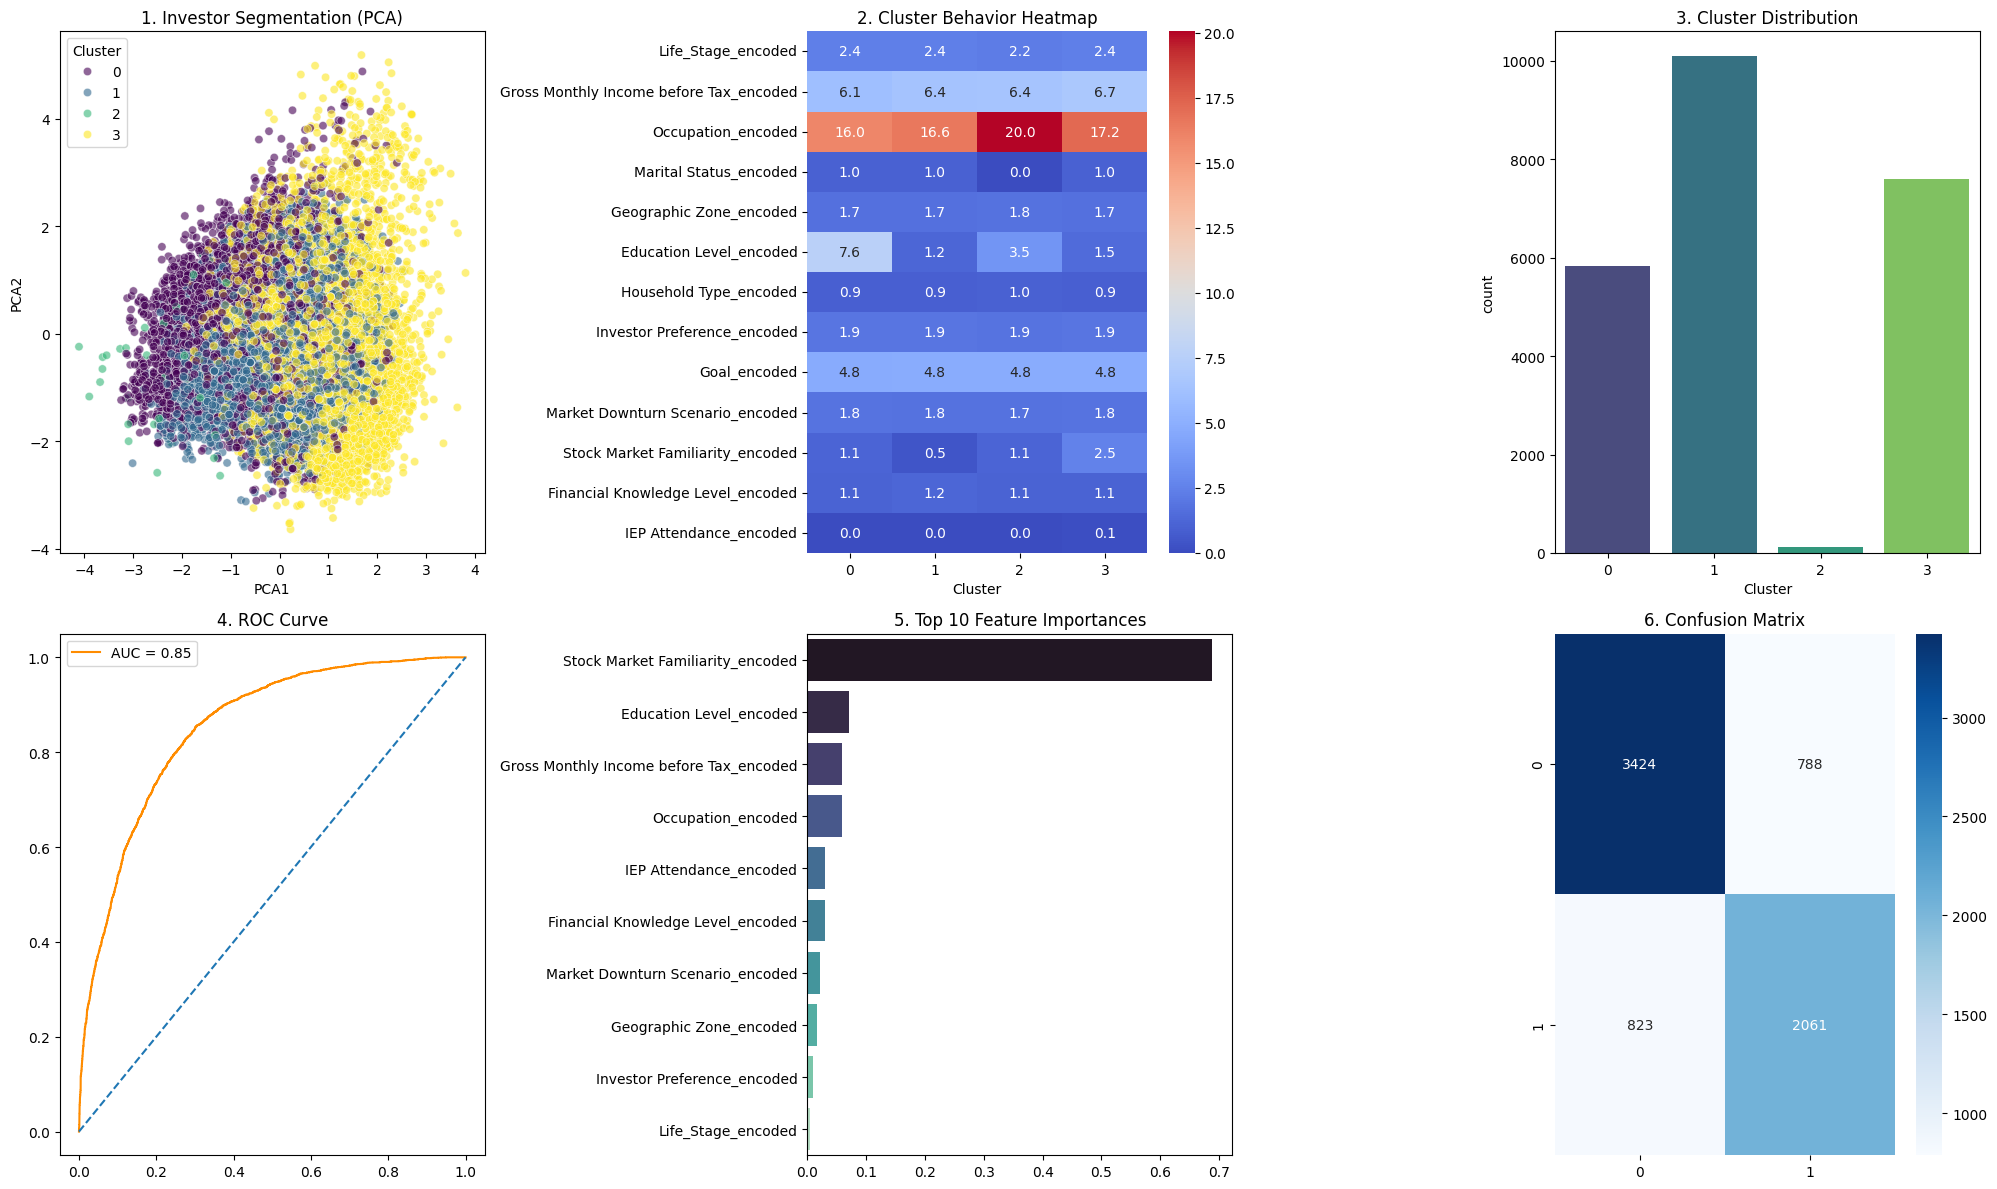

HTML(value="<h2 style='color:#2a75d3;'>Investment Predictor</h2>")

Dropdown(description='Asset Class:', layout=Layout(width='400px'), options={'Futures & Options (F&O)': 'ADI_Da…

Button(button_style='success', description='Predict Adoption Probability', layout=Layout(width='300px'), style…

Output()

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings

%matplotlib inline
warnings.filterwarnings('ignore')

file_path = "/content/Copy of Copy of Respondent Data.XLSX"
try:
    df_raw = pd.read_excel(file_path)
except FileNotFoundError:
    print(f" Could not find '{file_path}'.")
    raise

product_cols = [c for c in df_raw.columns if 'ADI_Dashboard' in c]
product_mapping = {col: str(df_raw.iloc[0][col]).split(':')[0].strip() for col in product_cols}
df_clean = df_raw.drop(0).reset_index(drop=True)

demographics = ['Life_Stage', 'Gross Monthly Income before Tax', 'Occupation', 'Marital Status', 'Geographic Zone', 'Education Level', 'Household Type']
inv_behavior = ['Investor Preference', 'Goal', 'Market Downturn Scenario']
literacy_media = ['Stock Market Familiarity', 'Financial Knowledge Level', 'IEP Attendance']
target_col = 'Investor Status'
features = demographics + inv_behavior + literacy_media

for col in features + [target_col]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_model = df_clean.copy()
df_model['Target'] = df_model[target_col].apply(lambda x: 1 if x == 'INVESTOR' else 0)

encoders = {}
encoded_features = []
for col in features:
    le = LabelEncoder()
    df_model[col + '_encoded'] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le
    encoded_features.append(col + '_encoded')

X_full = df_model[encoded_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_model['Cluster'] = kmeans.fit_predict(X_scaled)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_model['PCA1'] = X_pca[:, 0]
df_model['PCA2'] = X_pca[:, 1]

cluster_dummies = pd.get_dummies(df_model['Cluster'], prefix='Cluster')
X_sup = pd.concat([X_full, cluster_dummies], axis=1)
y_sup = df_model['Target']
X_train, X_test, y_train, y_test = train_test_split(X_sup, y_sup, test_size=0.3, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

sns.scatterplot(data=df_model, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', alpha=0.6, ax=axes[0,0])
axes[0,0].set_title('1. Investor Segmentation (PCA)')

cluster_means = df_model.groupby('Cluster')[encoded_features].mean()
sns.heatmap(cluster_means.T, annot=True, cmap='coolwarm', fmt=".1f", ax=axes[0,1])
axes[0,1].set_title('2. Cluster Behavior Heatmap')

sns.countplot(data=df_model, x='Cluster', palette='viridis', ax=axes[0,2])
axes[0,2].set_title('3. Cluster Distribution')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1,0].plot(fpr, tpr, color='darkorange', label=f'AUC = {auc(fpr, tpr):.2f}')
axes[1,0].plot([0,1], [0,1], linestyle='--')
axes[1,0].set_title('4. ROC Curve')
axes[1,0].legend()

importances = gb_model.feature_importances_
indices = np.argsort(importances)[::-1]
sns.barplot(x=importances[indices][:10], y=[X_sup.columns[i] for i in indices[:10]], palette='mako', ax=axes[1,1])
axes[1,1].set_title('5. Top 10 Feature Importances')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,2])
axes[1,2].set_title('6. Confusion Matrix')

plt.tight_layout()
plt.show()

valid_products = {name: col for col, name in product_mapping.items() if str(name).lower() != 'nan'}
asset_dropdown = widgets.Dropdown(options=valid_products, description='Asset Class:', style={'description_width': 'initial'}, layout=widgets.Layout(width='400px'))
feature_widgets = {col: widgets.Dropdown(options=sorted(df_clean[col].astype(str).unique().tolist()), description=f"{col}:", style={'description_width': 'initial'}, layout=widgets.Layout(width='350px')) for col in features}

left_col, right_col = widgets.VBox(list(feature_widgets.values())[:7]), widgets.VBox(list(feature_widgets.values())[7:])
profile_builder_ui = widgets.HBox([left_col, right_col], layout=widgets.Layout(margin='20px 0px'))
predict_btn = widgets.Button(description='Predict Adoption Probability', button_style='success', layout=widgets.Layout(width='300px'))
output_area = widgets.Output()

def on_predict_clicked(b):
    with output_area:
        clear_output()
        y_target = df_model[asset_dropdown.value].astype(str).str.contains('Active|Dormant', case=False, na=False).astype(int)
        rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced').fit(X_full, y_target)
        user_profile = [encoders[col].transform([feature_widgets[col].value])[0] for col in features]
        print(f"\n Predicted probability: {rf.predict_proba([user_profile])[0][1] * 100:.2f}%")

predict_btn.on_click(on_predict_clicked)
display(widgets.HTML("<h2 style='color:#2a75d3;'>Investment Predictor</h2>"), asset_dropdown, profile_builder_ui, predict_btn, output_area)